In [7]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils .data import DataLoader
from torchvision import datasets, transforms
from torchvision import models

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    top_k_accuracy_score,
    balanced_accuracy_score
)

DATA_ROOT = Path(r"/home/sergiocloudwork/dataset/sampled_500")

TEST_DIR = DATA_ROOT / "val"
MODEL_PATH = "inat_resnet50_500classes_imagenet.pth"
MODEL_PATH = "inat_resnet50_500_ptclasses_imagenet.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [8]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

classes = checkpoint["classes"]
num_classes = checkpoint["num_classes"]

print("Number of classes:", num_classes)
print("Classes:", classes)

Number of classes: 500
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00128_Animalia_Arthropoda_Arachnida_Araneae_Thomisidae_Synema_globosum', '00145_Animalia_Arthropoda_Arachnida_Opiliones_Phalangiidae_Phalangium_opilio', '00159_Animalia_Arthropoda_Chilopoda_Scolopendromorpha_Scolopendridae_Scolopendra_heros', '00203_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Cicindela_hirticollis', '00216_Animalia_Arthropoda_Insecta_Coleoptera_Carabidae_Scaphinotus_angusticollis', '00230_Animalia_Arthropoda_Insecta_Coleoptera_Cerambycidae_Knulliana_cincta', '00234_

In [9]:
test_transform = transforms.Compose([
    transforms.Resize(
        352,
        interpolation=transforms.InterpolationMode.BILINEAR,
        antialias=True
    ),
    transforms.CenterCrop(320),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

assert test_dataset.classes == classes, (
    "different testing set"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Test images:", len(test_dataset))

Test images: 5000


In [10]:
model = models.resnet50(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [11]:
correct = 0
total = 0

all_predictions = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_probs.append(probs.cpu())
        all_predictions.extend(predictions.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

test_accuracy = correct / total

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Correct predictions: {correct}/{total}")

Test accuracy: 0.7596
Correct predictions: 3798/5000


In [12]:
y_true = np.array(all_labels)
y_pred = np.array(all_predictions)
all_probs = torch.cat(all_probs).numpy()

top5_accuracy = top_k_accuracy_score(
    y_true, all_probs, k=5, labels=list(range(num_classes))
)

macro_precision = precision_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

balance_accuracy = balanced_accuracy_score(y_true, y_pred)

print(f"Top-1 Accuracy:    {test_accuracy:.4f}")
print(f"Top5 Accuracy:    {top5_accuracy:.4f}")
print(f"Macro Precision:  {macro_precision:.4f}")
print(f"Macro Recall:     {macro_recall:.4f}")
print(f"Macro F1:         {macro_f1:.4f}")
print(f"Weighted F1:      {weighted_f1:.4f}")
print(f"Balanced Accuracy:      {balance_accuracy:.4f}")

Top-1 Accuracy:    0.7596
Top5 Accuracy:    0.9122
Macro Precision:  0.7787
Macro Recall:     0.7596
Macro F1:         0.7589
Weighted F1:      0.7589
Balanced Accuracy:      0.7596


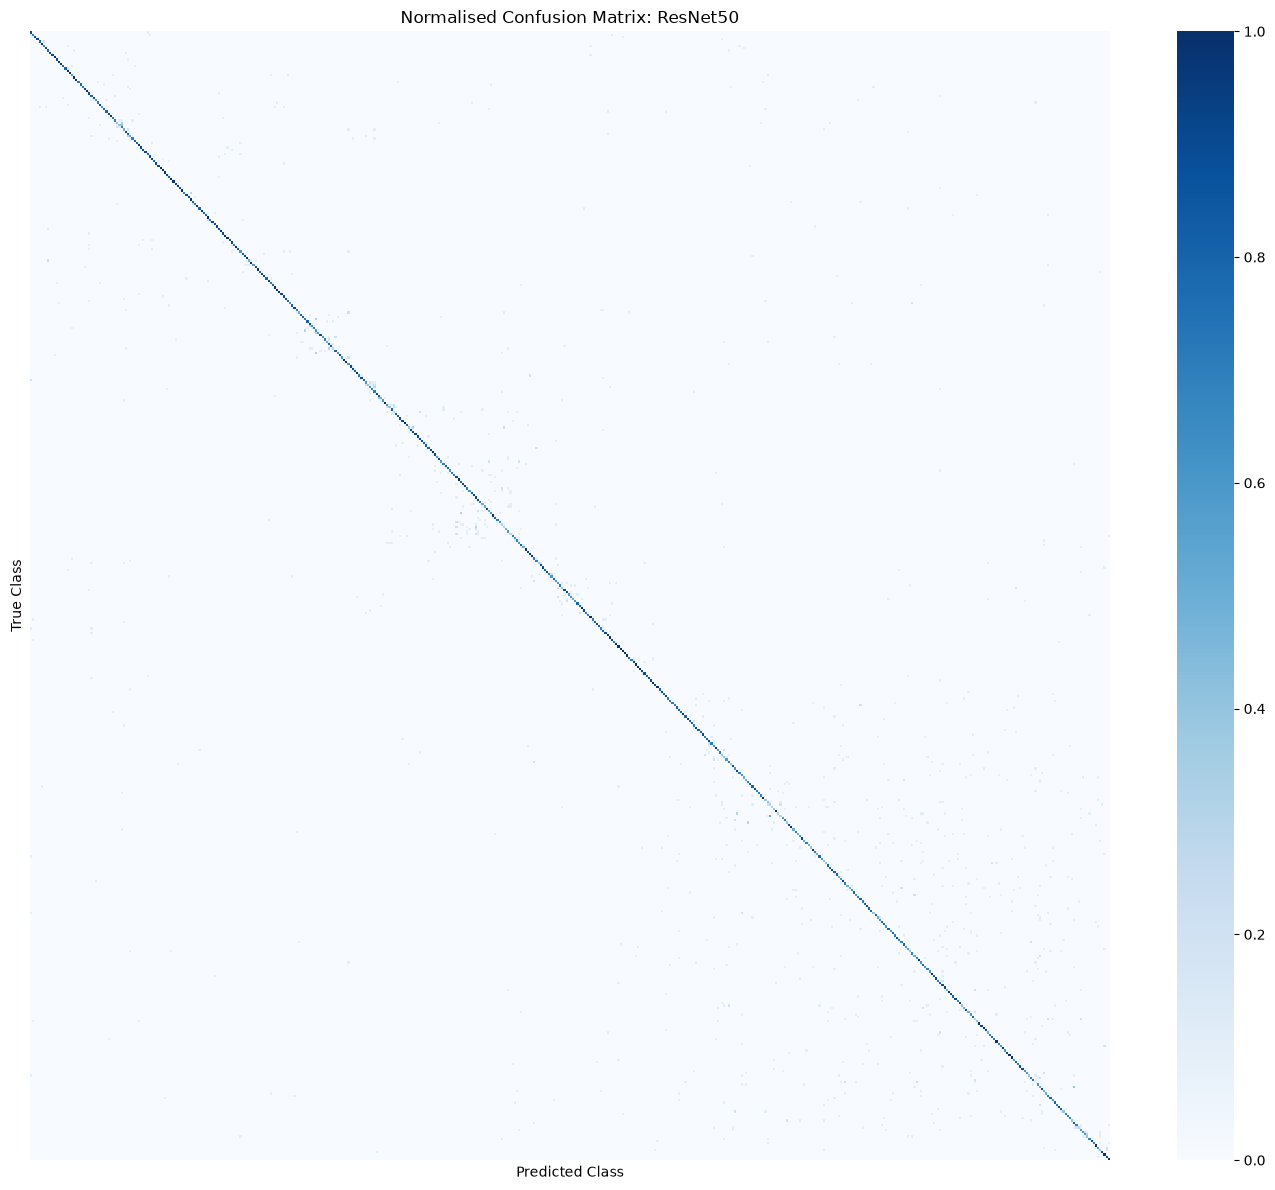

In [13]:
class_names = test_dataset.classes
num_classes = len(class_names)

cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    labels=range(num_classes),
    normalize="true"
)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    ax=ax
)

ax.set_title("Normalised Confusion Matrix: ResNet50")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

fig.tight_layout()
plt.show()